# Notebook 02: **Single-Frame Reflectivity-Style Analysis**

---

## 1. Purpose of This Notebook

Notebook 01 proved that the SemanticKITTI loading pipeline works correctly:
we successfully loaded a LiDAR frame, verified label alignment, computed range,
and observed that the raw geometric and intensity values are numerically plausible.

Now we move one level deeper.

The purpose of Notebook 02 is to study, on **one single LiDAR frame**, whether
raw intensity and a simple **pseudo-reflectivity** feature reveal meaningful scene structure.

This notebook is still intentionally conservative.

We are **not** claiming full physical reflectivity recovery.
We are **not** training a segmentation model.
We are **not** yet doing long temporal analysis.

Instead, this notebook asks a clean and important question:

> If raw intensity is corrected in a simple range-aware way, does the resulting signal become more interpretable for robotic scene understanding?

That is the central concept of Notebook 02.

## 2. Conceptual Motivation

A LiDAR point cloud gives us more than just geometry.

Each point contains:

- its 3D location.
- its return intensity.

For a point represented as

$$
p = (x, y, z, I)
$$

the intensity $I$ is often treated as a useful extra cue.
However, raw intensity is **not** a pure material property.
It is affected by measurement geometry, especially distance from the sensor,
and in more complete physics, also by angle of incidence and sensor behavior.

A common physical interpretation is:

$$
I \propto \frac{\rho \cos(\alpha)}{R^2}
$$


where:

- $I$ = measured intensity.
- $\rho$ = surface reflectivity.
- $\alpha$ = incidence angle.
- $R$ = range from the sensor.

This means raw intensity mixes together:

- intrinsic surface behavior.
- geometric distance effects.
- angular effects.
- sensor-specific effects.

So if we look only at raw intensity, we are seeing a signal that is partly about the scene,
and partly about the measurement process itself.

That is why this notebook introduces a simplified **pseudo-reflectivity** feature.

## 3. Mathematical Model Used in This Notebook

### 3.1 Point Representation

Each LiDAR point is:

$$
p_i = (x_i, y_i, z_i, I_i)
$$

where $(x_i, y_i, z_i)$ are 3D coordinates and $I_i$ is the raw intensity.

### 3.2 Range Computation

For each point, we compute Euclidean range:

$$
R_i = \sqrt{x_i^2 + y_i^2 + z_i^2}
$$

This range was already introduced in Notebook 01, but here it becomes a central variable.

### 3.3 Signal Interpretation

A simplified LiDAR return model suggests:

$$
I_i \propto \frac{\rho_i \cos(\alpha_i)}{R_i^2}
$$

A full reflectivity recovery would therefore require compensating not only for range,
but also for incidence angle and sensor calibration terms.

That is outside the scope of this preliminary notebook.

### 3.4 Pseudo-Reflectivity Approximation

Since we do **not** have full calibration terms available, we define a heuristic feature:

$$
\hat{\rho}_i = I_i \cdot R_i^k
$$

where $k$ is a chosen compensation exponent.

A simple and practical starting choice is:

$$
\hat{\rho}_i = I_i \cdot R_i
$$

and we may also inspect stronger compensation such as:

$$
\hat{\rho}_i = I_i \cdot R_i^2
$$

The important honesty note is this:

- \(\hat{\rho}\) is **not true calibrated reflectivity**.
- it is only a **range-aware pseudo-reflectivity proxy**.
- its value lies in making the signal more interpretable than raw intensity alone.

So this notebook is about **signal shaping and analysis**, not about claiming physically exact reflectance recovery.

## 4. What We Will Do in This Notebook

This notebook will follow the same disciplined structure as Notebook 01.

### Step A: Reuse the verified data-loading setup

We will load the same SemanticKITTI frame using the already validated pipeline.

### Step B: Extract the raw channels

We will separate:

- $x, y, z$.
- intensity $I$.
- range $R$.

### Step C: Compute pseudo-reflectivity

We will define one or more pseudo-reflectivity variants, beginning with a simple range-compensated form such as:

$$
\hat{\rho} = I \cdot R
$$

and possibly compare it with:

$$
\hat{\rho}_{(2)} = I \cdot R^2
$$

### Step D: Compare raw intensity and pseudo-reflectivity statistically

We will compute descriptive summaries such as:

- minimum.
- maximum.
- mean.
- standard deviation.
- selected quantiles.

for both raw intensity and pseudo-reflectivity.

### Step E: Compare them visually

We will generate plots such as:

- histogram of raw intensity.
- histogram of pseudo-reflectivity.
- bird’s-eye-view colored by raw intensity.
- bird’s-eye-view colored by pseudo-reflectivity.

### Step F: Inspect range dependence directly

We will analyze how the signal changes with range, for example through:

- scatter of intensity vs range.
- scatter of pseudo-reflectivity vs range.
- binned summaries across distance intervals.

This is especially important because the whole point of pseudo-reflectivity is to reduce raw distance dominance.

### Step G: Discuss what changed

We will interpret whether pseudo-reflectivity appears:

- more spatially structured.
- less dominated by near-sensor effects.
- more useful as a scene-understanding cue.

## 5. What We Are Trying to Achieve

The goal is not to prove a grand theorem.
The goal is to produce **clean evidence** that a simple range-aware feature changes the signal in a meaningful way.

More specifically, we want to see whether pseudo-reflectivity:

1. spreads the signal differently than raw intensity.
2. reduces obvious range bias at least partially.
3. highlights scene regions differently in top-view visualization.
4. looks promising enough to justify later multi-frame analysis.

If this happens, then Notebook 02 becomes the bridge between:

- Notebook 01: “the data is loaded correctly”.
- Notebook 03: “the reflectivity-style signal remains meaningful through motion”.

So Notebook 02 is the first real signal-analysis checkpoint of the project.

## 6. Expected Outputs

By the end of this notebook, we expect to have:

- one selected LiDAR frame loaded correctly.
- raw intensity available as a baseline signal.
- at least one pseudo-reflectivity feature computed.
- statistical comparison between intensity and pseudo-reflectivity.
- visual comparison between the two signals.
- preliminary evidence about whether range compensation reveals cleaner structure.

## 7. Expected Outcome

If everything goes well, the final takeaway of Notebook 02 should be something like this:

> Raw intensity carries useful information, but it is strongly entangled with range. A simple pseudo-reflectivity transformation does not fully recover physical reflectivity, yet it can produce a more interpretable, range-aware signal that is worth studying further.

That is the exact kind of result we want at this stage:
honest, useful, and strong enough to justify the next notebook.

## 8. Final Note

Notebook 01 was about trusting the pipeline.

Notebook 02 is about interrogating the signal.

No segmentation hero arc yet.
No temporal fireworks yet.
Just one frame, one idea, and a serious attempt to see whether
reflectivity-style reasoning actually gives us something real.

---

## Step 1: Reload one verified frame from the SemanticKITTI sequence

We begin by reusing the validated loading setup from Notebook 01.

The goal of this step is simple:
load one LiDAR frame, load its matching label file, and recover the basic raw channels
that Notebook 02 will build on top of.

No reflectivity-style transformation yet.
Right now we are just reconstructing the clean starting state for single-frame analysis.

In [1]:
from pathlib import Path
import numpy as np

# Notebook is assumed to run from notebooks/
DATASET_ROOT = Path("../data/semantickitti_subset/dataset/sequences/00")
FRAME_ID = "000000"

bin_path = DATASET_ROOT / "velodyne" / f"{FRAME_ID}.bin"
label_path = DATASET_ROOT / "labels" / f"{FRAME_ID}.label"

points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
labels = np.fromfile(label_path, dtype=np.uint32)

xyz = points[:, :3]
intensity = points[:, 3]
ranges = np.linalg.norm(xyz, axis=1)

semantic_labels = labels & 0xFFFF
instance_labels = labels >> 16

print("FRAME ID:", FRAME_ID)
print("Point cloud shape:", points.shape)
print("Label shape:", labels.shape)
print("XYZ shape:", xyz.shape)
print("Intensity shape:", intensity.shape)
print("Ranges shape:", ranges.shape)
print("Point-label aligned:", len(points) == len(labels))

print("\nFirst 3 points:")
print(points[:3])

print("\nFirst 10 semantic labels:")
print(semantic_labels[:10])

print("\nFirst 10 instance labels:")
print(instance_labels[:10])

FRAME ID: 000000
Point cloud shape: (124668, 4)
Label shape: (124668,)
XYZ shape: (124668, 3)
Intensity shape: (124668,)
Ranges shape: (124668,)
Point-label aligned: True

First 3 points:
[[5.2897942e+01 2.2989739e-02 1.9979945e+00 7.9999998e-02]
 [5.3750526e+01 1.9291429e-01 2.0269539e+00 0.0000000e+00]
 [5.3803116e+01 3.6183926e-01 2.0289137e+00 0.0000000e+00]]

First 10 semantic labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 instance labels:
[0 0 0 0 0 0 0 0 0 0]


## Step 2: Define simple range-aware pseudo-reflectivity features

Now that the raw frame is loaded, we construct simple reflectivity-style proxy signals.

These are not physically calibrated reflectivity values.
They are heuristic range-aware transformations of raw intensity that let us inspect
whether compensating for distance reveals a more interpretable signal structure.

In [2]:
# Small epsilon for numerical safety, though ranges here should already be > 0.
eps = 1e-6

pseudo_reflectivity_r1 = intensity * np.maximum(ranges, eps)
pseudo_reflectivity_r2 = intensity * np.maximum(ranges, eps) ** 2

print("Pseudo-reflectivity features created.")
print("r1 shape:", pseudo_reflectivity_r1.shape)
print("r2 shape:", pseudo_reflectivity_r2.shape)

print("\nFirst 10 raw intensity values:")
print(intensity[:10])

print("\nFirst 10 pseudo-reflectivity values: I * R")
print(pseudo_reflectivity_r1[:10])

print("\nFirst 10 pseudo-reflectivity values: I * R^2")
print(pseudo_reflectivity_r2[:10])

Pseudo-reflectivity features created.
r1 shape: (124668,)
r2 shape: (124668,)

First 10 raw intensity values:
[0.08 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]

First 10 pseudo-reflectivity values: I * R
[4.2348533 0.        0.        0.        0.        0.        0.
 0.        0.        0.       ]

First 10 pseudo-reflectivity values: I * R^2
[224.17476   0.        0.        0.        0.        0.        0.
   0.        0.        0.     ]


**The pseudo-reflectivity proxies were computed correctly.**

**As expected, zero-intensity points remain zero, while nonzero returns are amplified by range, giving us range-aware signals that we can now compare statistically against raw intensity.**

## Step 3: Compare the three signals numerically

Before plotting anything, we first summarize the distributions of raw intensity and the two pseudo-reflectivity variants.

This helps us see how strongly the range-aware transformations change the scale and spread of the signal.

In [4]:
def describe_signal(name, values):
    q = np.percentile(values, [0, 25, 50, 75, 95, 99, 100])
    print(f"{name}")
    print(f"  min   : {q[0]:.6f}")
    print(f"  p25   : {q[1]:.6f}")
    print(f"  p50   : {q[2]:.6f}")
    print(f"  p75   : {q[3]:.6f}")
    print(f"  p95   : {q[4]:.6f}")
    print(f"  p99   : {q[5]:.6f}")
    print(f"  max   : {q[6]:.6f}")
    print(f"  mean  : {values.mean():.6f}")
    print(f"  std   : {values.std():.6f}")
    print()

describe_signal("Raw intensity", intensity)
describe_signal("Pseudo-reflectivity (I * R)", pseudo_reflectivity_r1)
describe_signal("Pseudo-reflectivity (I * R^2)", pseudo_reflectivity_r2)

Raw intensity
  min   : 0.000000
  p25   : 0.220000
  p50   : 0.300000
  p75   : 0.370000
  p95   : 0.540000
  p99   : 0.690000
  max   : 0.990000
  mean  : 0.294134
  std   : 0.147690

Pseudo-reflectivity (I * R)
  min   : 0.000000
  p25   : 1.669057
  p50   : 2.754553
  p75   : 5.201154
  p95   : 9.184167
  p99   : 12.255593
  max   : 58.805172
  mean  : 3.628692
  std   : 2.940125

Pseudo-reflectivity (I * R^2)
  min   : 0.000000
  p25   : 10.098474
  p50   : 24.684789
  p75   : 76.925367
  p95   : 233.098367
  p99   : 416.893155
  max   : 3991.761475
  mean  : 61.607342
  std   : 98.882828



**The statistics show that range compensation significantly expands the signal distribution.**

**Among the two proxies, $I \cdot R$ remains relatively controlled, while $I \cdot R^2$ develops a much heavier upper tail, suggesting stronger but less stable range amplification.**

## Step 4: Measure how each signal relates to distance from the sensor

Since the main motivation of this notebook is range-aware signal analysis,
we now check how strongly each signal correlates with range.

This gives us a quick numerical sense of whether the transformed signals remain strongly distance-driven.

In [5]:
corr_intensity_range = np.corrcoef(intensity, ranges)[0, 1]
corr_r1_range = np.corrcoef(pseudo_reflectivity_r1, ranges)[0, 1]
corr_r2_range = np.corrcoef(pseudo_reflectivity_r2, ranges)[0, 1]

print(f"Correlation between raw intensity and range      : {corr_intensity_range:.6f}")
print(f"Correlation between pseudo-reflectivity I*R and range   : {corr_r1_range:.6f}")
print(f"Correlation between pseudo-reflectivity I*R^2 and range : {corr_r2_range:.6f}")

Correlation between raw intensity and range      : -0.231389
Correlation between pseudo-reflectivity I*R and range   : 0.398455
Correlation between pseudo-reflectivity I*R^2 and range : 0.568631


**Raw intensity decreases with range, but both compensated signals reverse that trend.**

**This suggests that range correction is working in principle, but $I \cdot R^2$ appears to overcompensate, while $I \cdot R$ remains the more reasonable first proxy.**

**The analysis confirms that raw intensity is range-dependent, and that simple range-aware transformations substantially change this behavior. Among the tested proxies, $I \cdot R$ appears to be the more stable and interpretable choice, while $I \cdot R^2$ appears to overcompensate.**

## Step 5: Visualize the signal distributions

Numerical summaries are useful, but plots make the distributional differences much easier to see.

We now compare the histograms of raw intensity, $I \cdot R$, and $I \cdot R^2$.

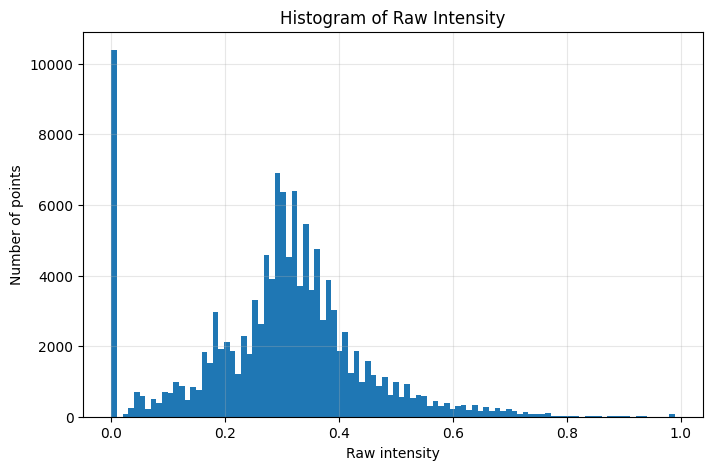

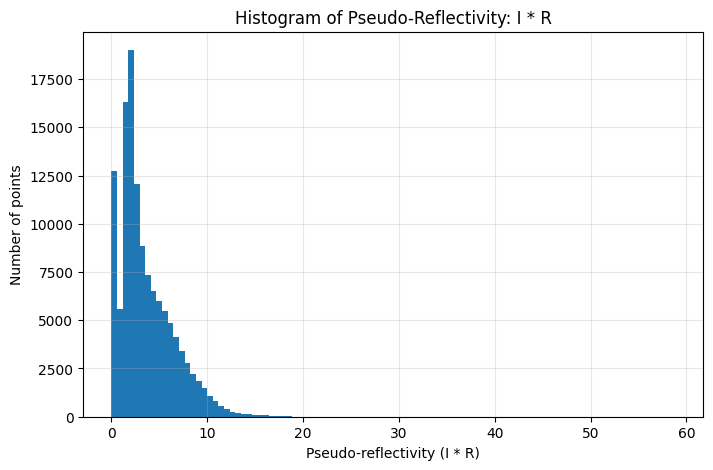

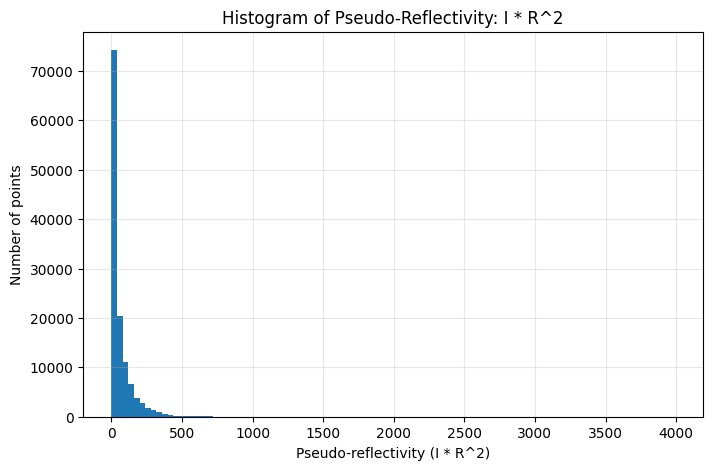

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(intensity, bins=100)
plt.xlabel("Raw intensity")
plt.ylabel("Number of points")
plt.title("Histogram of Raw Intensity")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(pseudo_reflectivity_r1, bins=100)
plt.xlabel("Pseudo-reflectivity (I * R)")
plt.ylabel("Number of points")
plt.title("Histogram of Pseudo-Reflectivity: I * R")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(pseudo_reflectivity_r2, bins=100)
plt.xlabel("Pseudo-reflectivity (I * R^2)")
plt.ylabel("Number of points")
plt.title("Histogram of Pseudo-Reflectivity: I * R^2")
plt.grid(True, alpha=0.3)
plt.show()

**The histogram comparison reinforces the earlier numerical results.**

**Raw intensity remains compact but range-entangled, $I \cdot R$ produces a broader yet still interpretable distribution, and $I \cdot R^2$ becomes heavily skewed with an extreme tail, indicating overcompensation.**

## Step 6: Evaluate semantic usefulness using both metrics and plots

Global histograms describe the overall signal, but they do not tell us whether the signal helps distinguish semantic classes.

So in this step, we do both:
1. compute a simple class-separability metric, and
2. visualize class-wise signal distributions for the main semantic classes in the frame.

This lets us judge the transformed signal numerically as well as visually.

Valid classes used for analysis:
  Class 10: 4234 points
  Class 40: 34228 points
  Class 44: 3268 points
  Class 48: 26360 points
  Class 50: 18268 points
  Class 52: 1471 points
  Class 60: 1053 points
  Class 70: 27123 points
  Class 71: 1192 points
  Class 72: 2964 points
  Class 80: 532 points
  Class 99: 1227 points

Class-separability score (higher is better):
  Raw intensity           : 0.38142828
  Pseudo-reflectivity I*R : 0.57723763

Per-class mean values:
  Class  10 | mean(I) = 0.153462 | mean(I*R) = 2.553735 | n = 4234
  Class  40 | mean(I) = 0.213374 | mean(I*R) = 1.895020 | n = 34228
  Class  44 | mean(I) = 0.299865 | mean(I*R) = 3.833581 | n = 3268
  Class  48 | mean(I) = 0.300424 | mean(I*R) = 2.472348 | n = 26360
  Class  50 | mean(I) = 0.428269 | mean(I*R) = 6.293034 | n = 18268
  Class  52 | mean(I) = 0.344582 | mean(I*R) = 4.121638 | n = 1471
  Class  60 | mean(I) = 0.408528 | mean(I*R) = 2.683908 | n = 1053
  Class  70 | mean(I) = 0.333848 | mean(I*R) = 4.861657 

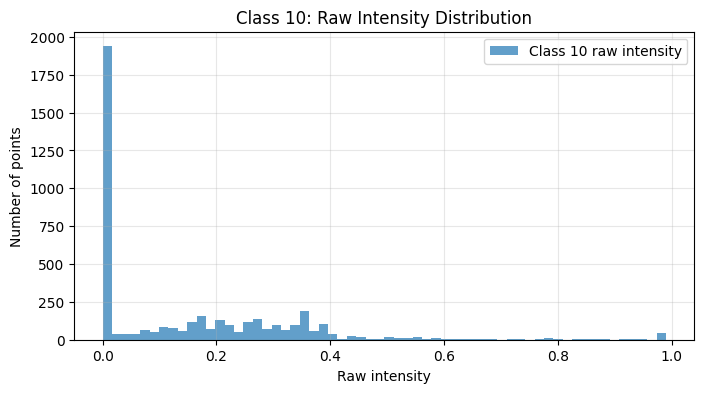

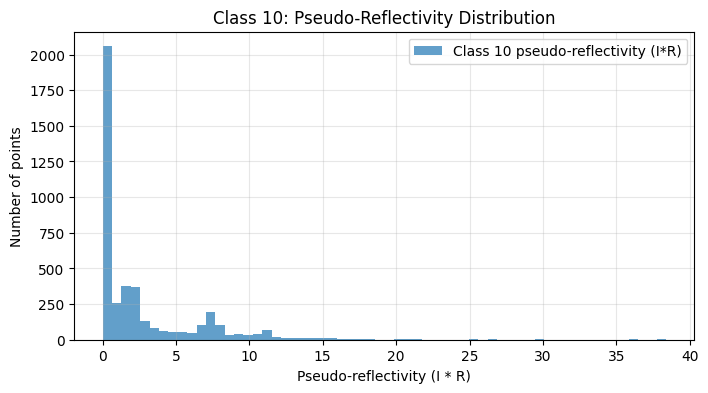

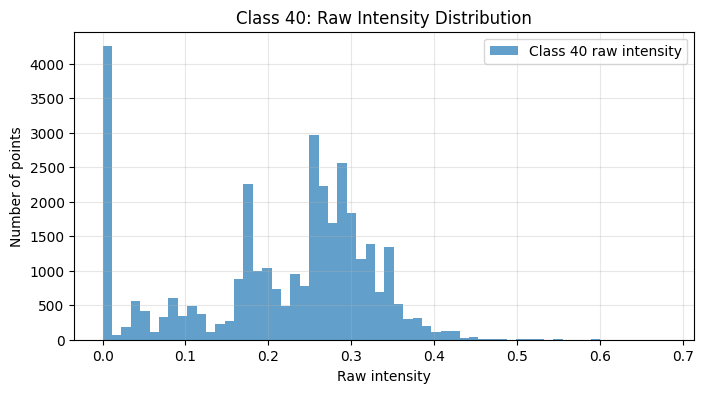

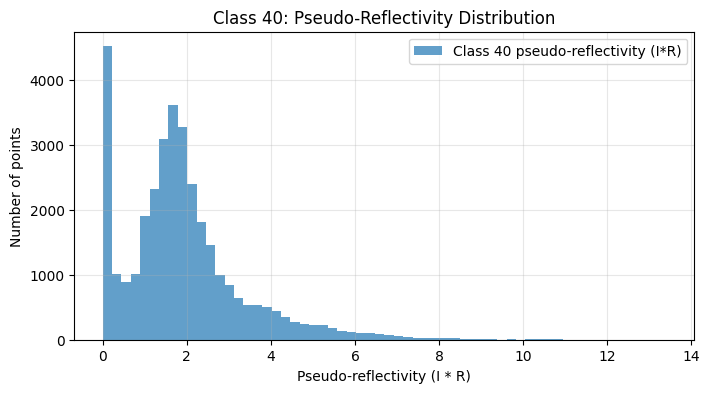

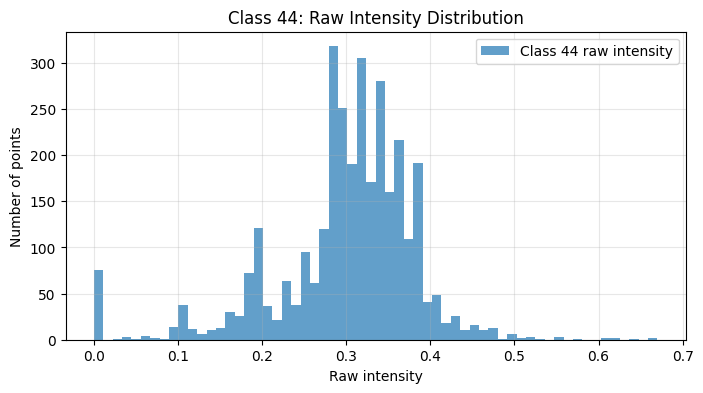

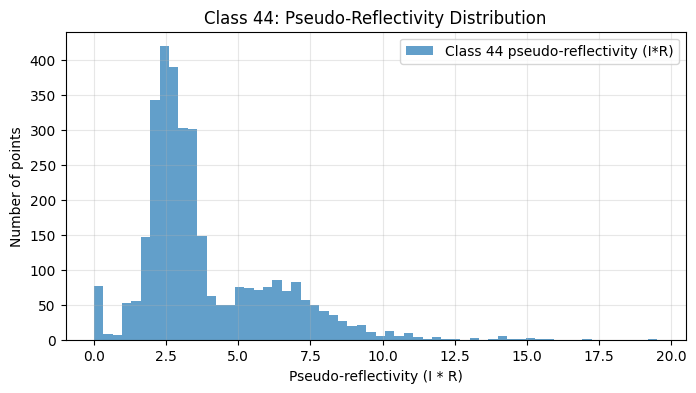

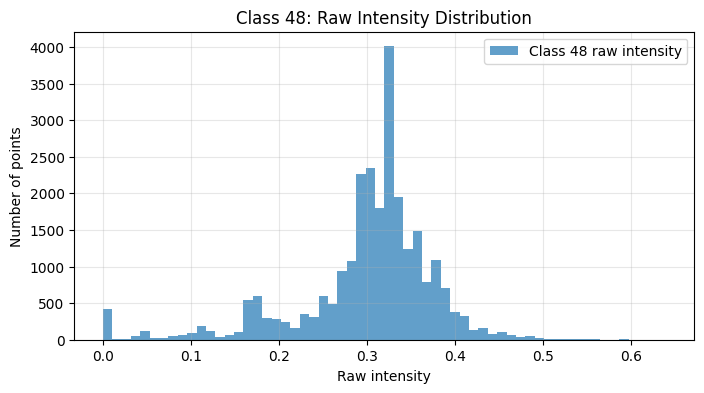

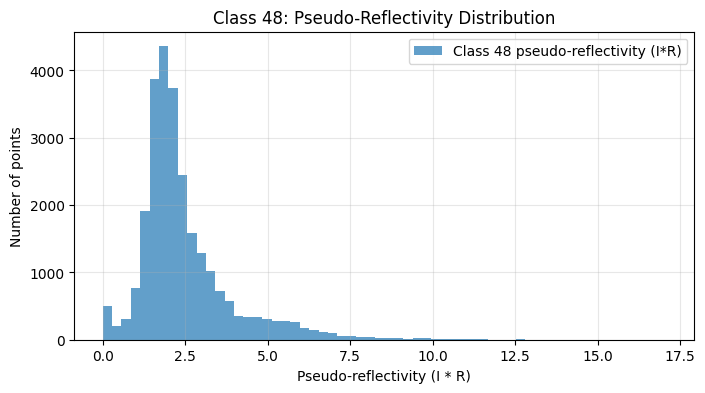

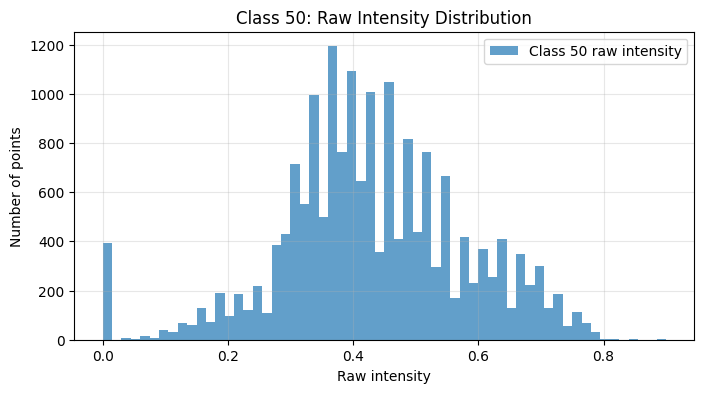

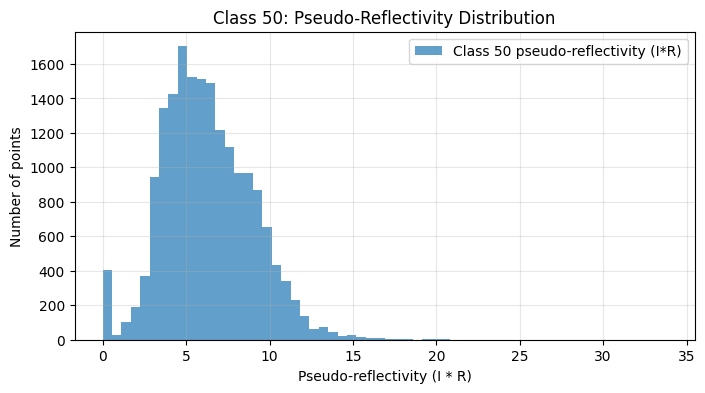

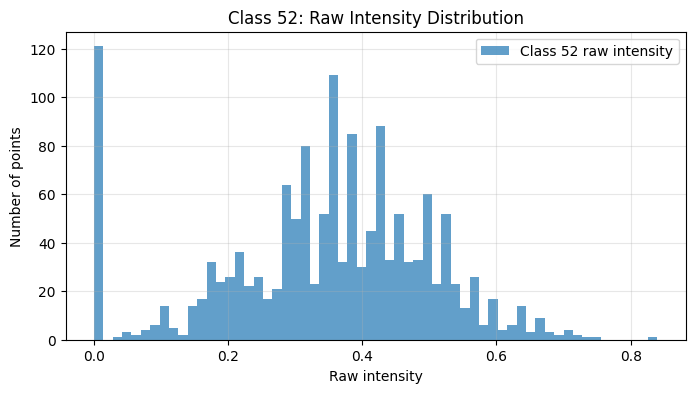

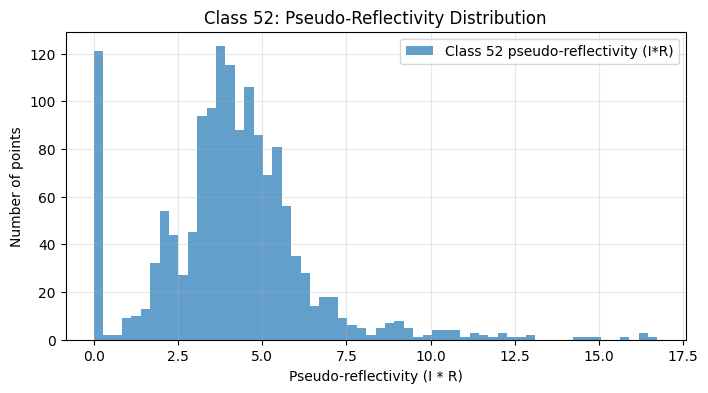

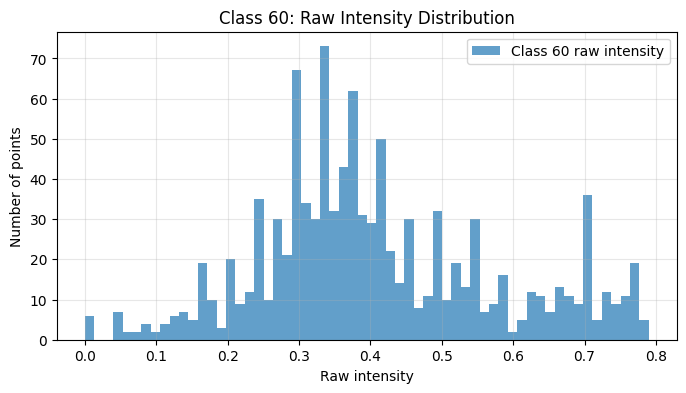

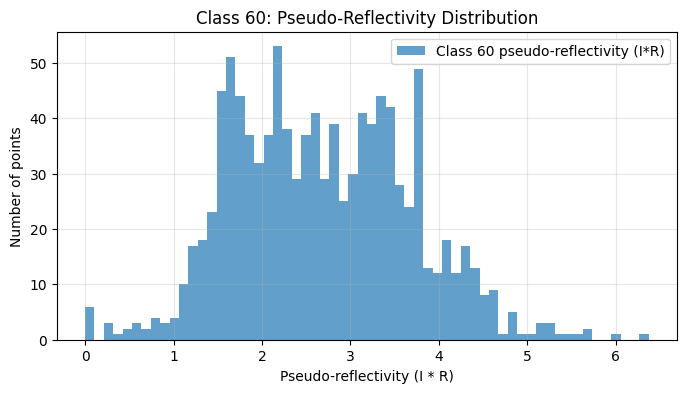

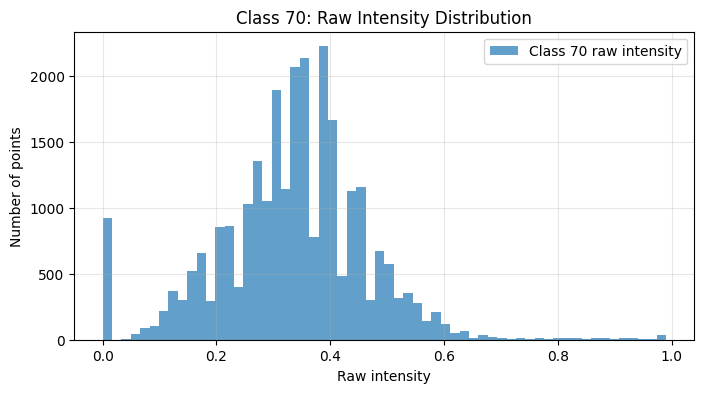

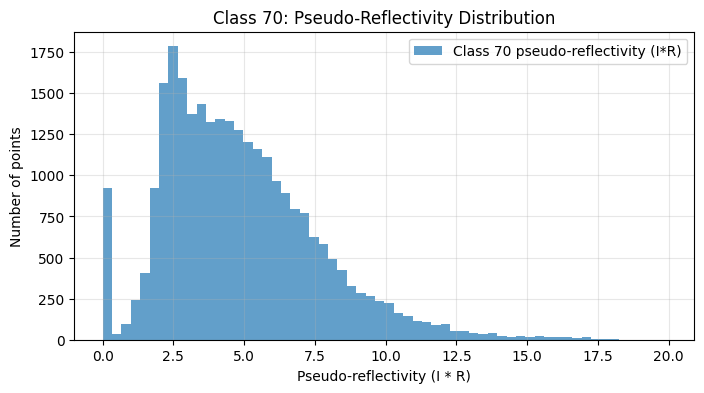

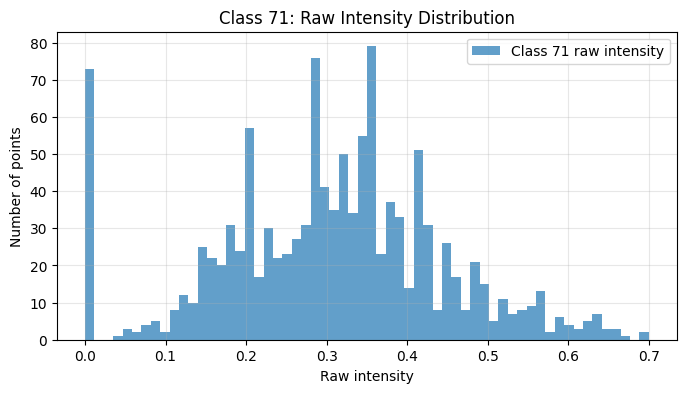

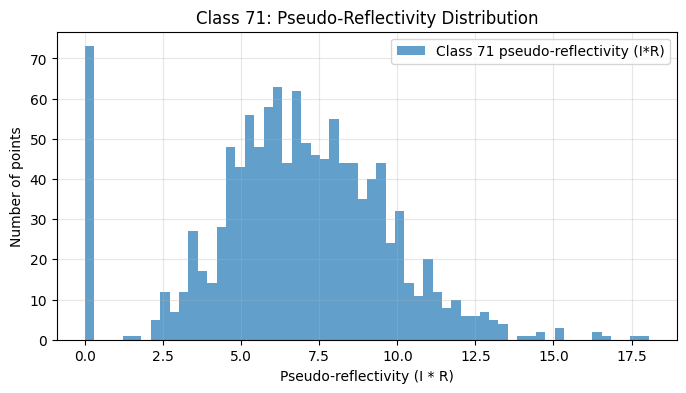

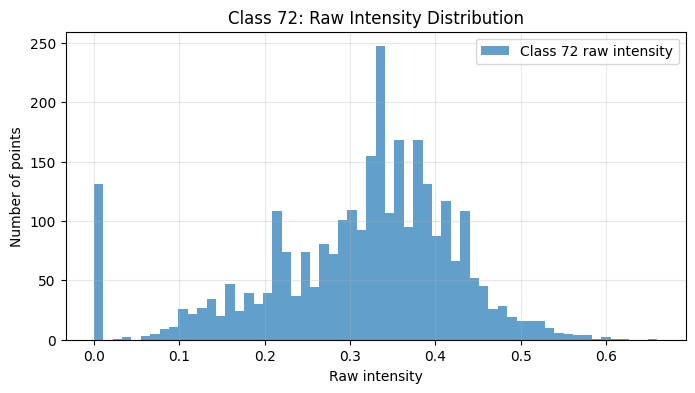

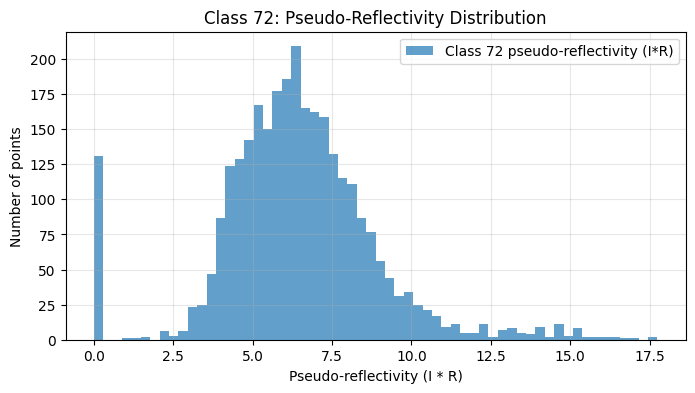

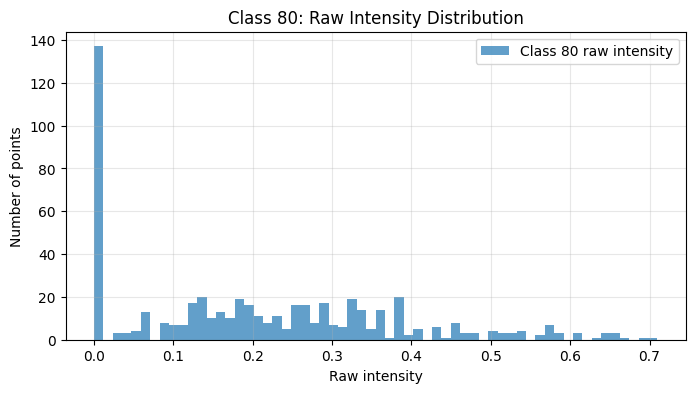

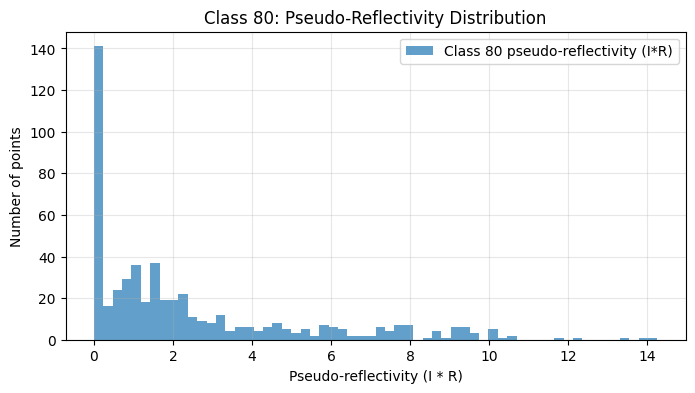

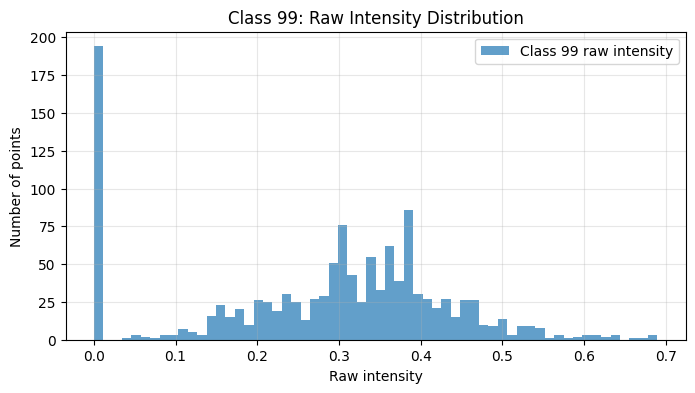

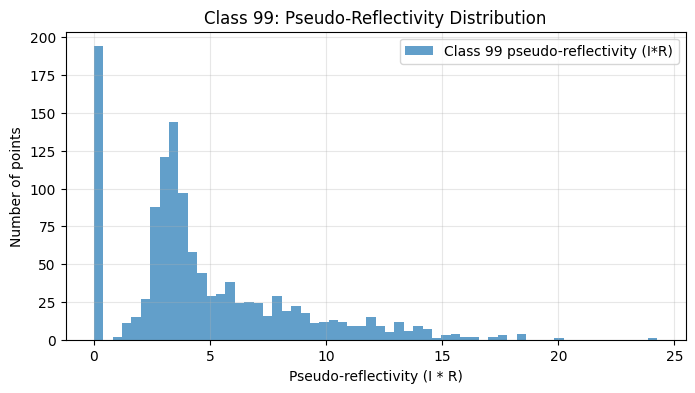

In [9]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Exclude unlabeled / ignored classes
ignore_labels = {0, 255}

# Count classes in this frame
class_counts = Counter(semantic_labels.tolist())

# Keep only classes with enough support
min_points = 500
valid_classes = sorted([
    cls for cls, cnt in class_counts.items()
    if cls not in ignore_labels and cnt >= min_points
])

print("Valid classes used for analysis:")
for cls in valid_classes:
    print(f"  Class {cls}: {class_counts[cls]} points")


def fisher_separability(signal, labels, classes):
    class_means = []
    class_vars = []
    class_ns = []

    for cls in classes:
        vals = signal[labels == cls]
        class_means.append(vals.mean())
        class_vars.append(vals.var())
        class_ns.append(len(vals))

    class_means = np.array(class_means)
    class_vars = np.array(class_vars)
    class_ns = np.array(class_ns)

    global_mean = np.average(class_means, weights=class_ns)
    between = np.sum(class_ns * (class_means - global_mean) ** 2)
    within = np.sum(class_ns * class_vars)

    score = between / (within + 1e-12)
    return score, class_means, class_vars, class_ns


score_intensity, means_I, vars_I, ns = fisher_separability(
    intensity, semantic_labels, valid_classes
)
score_r1, means_R1, vars_R1, _ = fisher_separability(
    pseudo_reflectivity_r1, semantic_labels, valid_classes
)

print("\nClass-separability score (higher is better):")
print(f"  Raw intensity           : {score_intensity:.8f}")
print(f"  Pseudo-reflectivity I*R : {score_r1:.8f}")

print("\nPer-class mean values:")
for i, cls in enumerate(valid_classes):
    print(
        f"  Class {cls:>3} | "
        f"mean(I) = {means_I[i]:.6f} | "
        f"mean(I*R) = {means_R1[i]:.6f} | "
        f"n = {ns[i]}"
    )

# Plot class-wise histograms
for cls in valid_classes:
    vals_I = intensity[semantic_labels == cls]
    vals_R1 = pseudo_reflectivity_r1[semantic_labels == cls]

    plt.figure(figsize=(8, 4))
    plt.hist(vals_I, bins=60, alpha=0.7, label=f"Class {cls} raw intensity")
    plt.xlabel("Raw intensity")
    plt.ylabel("Number of points")
    plt.title(f"Class {cls}: Raw Intensity Distribution")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(vals_R1, bins=60, alpha=0.7, label=f"Class {cls} pseudo-reflectivity (I*R)")
    plt.xlabel("Pseudo-reflectivity (I * R)")
    plt.ylabel("Number of points")
    plt.title(f"Class {cls}: Pseudo-Reflectivity Distribution")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

**The class-separability score improves from raw intensity to $I \cdot R$, indicating that the range-aware proxy provides stronger semantic discrimination on this frame.**

**The class-wise histograms support the same conclusion: the transformed signal changes the distributions in a way that makes several classes more distinguishable than with raw intensity alone.**

## Step 7: Build FOV projections and summarize them with projection-space metrics

We now project the LiDAR frame into a simple angular field-of-view image.

This gives us sensor-view visualizations of range, raw intensity, pseudo-reflectivity, and semantic labels. Along with the images, we also compute projection-space metrics such as pixel coverage, collision count, and valid-pixel statistics to quantify the structure of the projected signals.

Projection-space metrics
  Image size                : 64 x 1024 = 65536 pixels
  Total input points        : 124668
  Valid projected pixels    : 50188
  Pixel coverage ratio      : 0.765808
  Pixel collision count     : 74480
  Pixel collision ratio     : 0.597427
  Unique projected classes  : 17
  Projected class IDs       : [0, 1, 10, 40, 44, 48, 50, 51, 52, 60, 70, 71, 72, 80, 81, 99, 255]

Projected range image stats
  valid pixels : 50188
  min          : 1.348360
  p25          : 6.416636
  p50          : 9.149655
  p75          : 14.091101
  p95          : 34.554153
  max          : 79.479065
  mean         : 12.547100
  std          : 9.983994

Projected raw intensity image stats
  valid pixels : 50188
  min          : 0.000000
  p25          : 0.210000
  p50          : 0.300000
  p75          : 0.360000
  p95          : 0.520000
  max          : 0.990000
  mean         : 0.288925
  std          : 0.146353

Projected pseudo-reflectivity (I * R) image stats
  valid pixels : 50

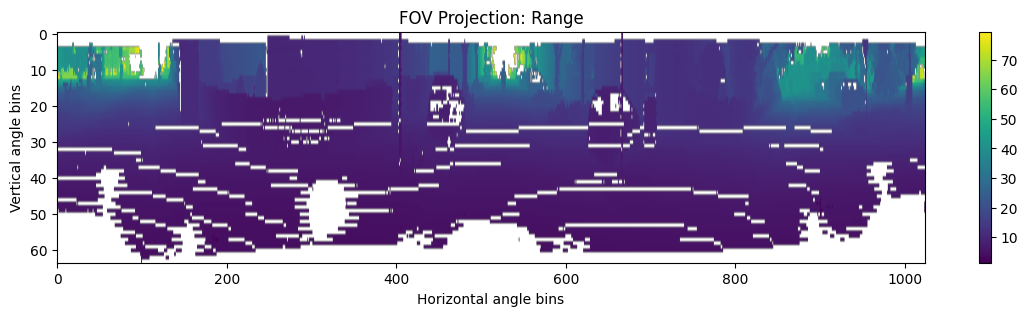

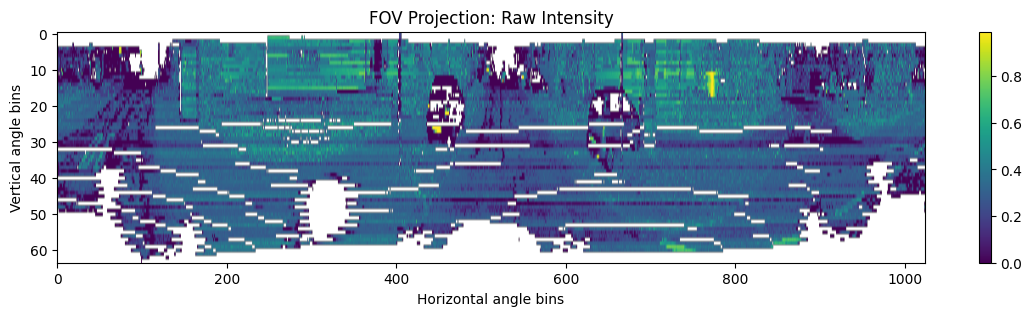

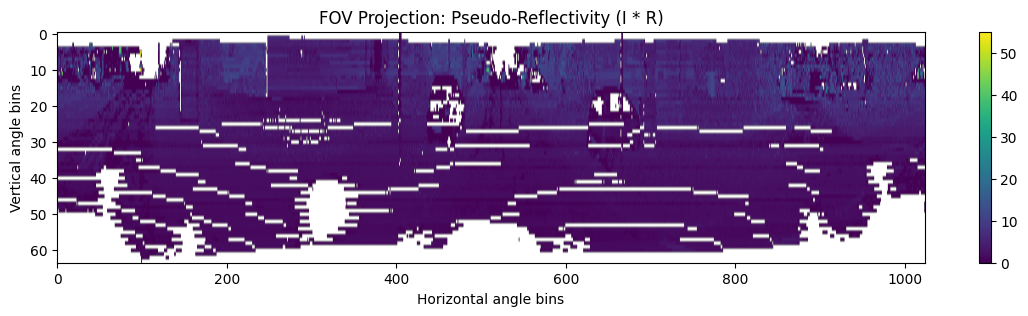

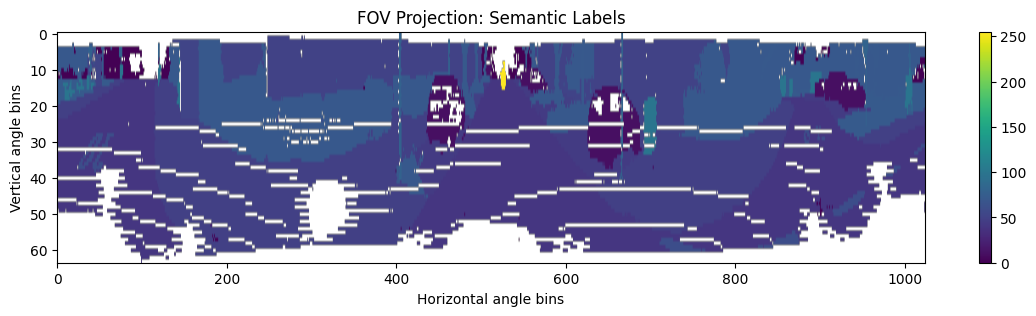

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Spherical projection

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

r = np.linalg.norm(xyz, axis=1) + 1e-6
yaw = np.arctan2(y, x)
pitch = np.arcsin(z / r)

W = 1024
H = 64

yaw_min, yaw_max = -np.pi, np.pi
pitch_min, pitch_max = pitch.min(), pitch.max()

u = ((yaw - yaw_min) / (yaw_max - yaw_min) * (W - 1)).astype(np.int32)
v = ((pitch_max - pitch) / (pitch_max - pitch_min) * (H - 1)).astype(np.int32)

u = np.clip(u, 0, W - 1)
v = np.clip(v, 0, H - 1)

# 2) Projection buffers

range_img = np.full((H, W), np.nan, dtype=np.float32)
intensity_img = np.full((H, W), np.nan, dtype=np.float32)
pseudo_r1_img = np.full((H, W), np.nan, dtype=np.float32)
semantic_img = np.full((H, W), np.nan, dtype=np.float32)

filled_mask = np.zeros((H, W), dtype=bool)
collision_count = 0

# Far-to-near so nearer points overwrite farther ones
order = np.argsort(r)[::-1]

for idx in order:
    row, col = v[idx], u[idx]
    if filled_mask[row, col]:
        collision_count += 1
    filled_mask[row, col] = True

    range_img[row, col] = r[idx]
    intensity_img[row, col] = intensity[idx]
    pseudo_r1_img[row, col] = pseudo_reflectivity_r1[idx]
    semantic_img[row, col] = semantic_labels[idx]

# 3) Projection-space metrics

total_pixels = H * W
valid_pixels = int(np.sum(filled_mask))
coverage_ratio = valid_pixels / total_pixels
points_projected = len(r)
collisions_ratio = collision_count / points_projected

def valid_stats(name, img):
    vals = img[~np.isnan(img)]
    print(f"{name}")
    print(f"  valid pixels : {len(vals)}")
    print(f"  min          : {vals.min():.6f}")
    print(f"  p25          : {np.percentile(vals, 25):.6f}")
    print(f"  p50          : {np.percentile(vals, 50):.6f}")
    print(f"  p75          : {np.percentile(vals, 75):.6f}")
    print(f"  p95          : {np.percentile(vals, 95):.6f}")
    print(f"  max          : {vals.max():.6f}")
    print(f"  mean         : {vals.mean():.6f}")
    print(f"  std          : {vals.std():.6f}")
    print()

projected_classes = np.unique(semantic_img[~np.isnan(semantic_img)]).astype(np.int32)

print("Projection-space metrics")
print(f"  Image size                : {H} x {W} = {total_pixels} pixels")
print(f"  Total input points        : {points_projected}")
print(f"  Valid projected pixels    : {valid_pixels}")
print(f"  Pixel coverage ratio      : {coverage_ratio:.6f}")
print(f"  Pixel collision count     : {collision_count}")
print(f"  Pixel collision ratio     : {collisions_ratio:.6f}")
print(f"  Unique projected classes  : {len(projected_classes)}")
print(f"  Projected class IDs       : {projected_classes.tolist()}")
print()

valid_stats("Projected range image stats", range_img)
valid_stats("Projected raw intensity image stats", intensity_img)
valid_stats("Projected pseudo-reflectivity (I * R) image stats", pseudo_r1_img)

# 4) Visualizations

plt.figure(figsize=(14, 3))
plt.imshow(range_img, aspect='auto')
plt.title("FOV Projection: Range")
plt.xlabel("Horizontal angle bins")
plt.ylabel("Vertical angle bins")
plt.colorbar()
plt.show()

plt.figure(figsize=(14, 3))
plt.imshow(intensity_img, aspect='auto')
plt.title("FOV Projection: Raw Intensity")
plt.xlabel("Horizontal angle bins")
plt.ylabel("Vertical angle bins")
plt.colorbar()
plt.show()

plt.figure(figsize=(14, 3))
plt.imshow(pseudo_r1_img, aspect='auto')
plt.title("FOV Projection: Pseudo-Reflectivity (I * R)")
plt.xlabel("Horizontal angle bins")
plt.ylabel("Vertical angle bins")
plt.colorbar()
plt.show()

plt.figure(figsize=(14, 3))
plt.imshow(semantic_img, aspect='auto')
plt.title("FOV Projection: Semantic Labels")
plt.xlabel("Horizontal angle bins")
plt.ylabel("Vertical angle bins")
plt.colorbar()
plt.show()

**The FOV projection is structurally valid, with substantial pixel coverage and expected point collisions due to angular binning.**

**In sensor-view space, raw intensity and $I \cdot R$ both preserve scene structure, while the pseudo-reflectivity image provides a transformed but still stable signal that remains consistent with the earlier statistical analysis.**

## Step 8: Summarize the main quantitative findings of Notebook 02

We now gather the most important results into one compact summary block.

This gives a clean final view of how raw intensity and the main pseudo-reflectivity proxy behaved in terms of range dependence, signal distribution, semantic separability, and FOV projection quality.

In [14]:
def signal_summary_dict(name, values):
    return {
        "name": name,
        "min": float(np.min(values)),
        "p25": float(np.percentile(values, 25)),
        "p50": float(np.percentile(values, 50)),
        "p75": float(np.percentile(values, 75)),
        "p95": float(np.percentile(values, 95)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
    }

summary_intensity = signal_summary_dict("Raw intensity", intensity)
summary_r1 = signal_summary_dict("Pseudo-reflectivity (I * R)", pseudo_reflectivity_r1)

print("NOTEBOOK 02: FINAL QUANTITATIVE SUMMARY")

print("\n[Range Dependence]")
print(f"corr(raw intensity, range)   = {corr_intensity_range:.6f}")
print(f"corr(I * R, range)          = {corr_r1_range:.6f}")

print("\n[Semantic Class Separability]")
print(f"raw intensity score         = {score_intensity:.6f}")
print(f"I * R score                 = {score_r1:.6f}")
print(f"absolute improvement        = {score_r1 - score_intensity:.6f}")
print(f"relative improvement        = {(score_r1 - score_intensity) / (score_intensity + 1e-12):.6f}")

print("\n[Global Signal Statistics]")
for s in [summary_intensity, summary_r1]:
    print(f"\n{s['name']}")
    print(f"  min   = {s['min']:.6f}")
    print(f"  p25   = {s['p25']:.6f}")
    print(f"  p50   = {s['p50']:.6f}")
    print(f"  p75   = {s['p75']:.6f}")
    print(f"  p95   = {s['p95']:.6f}")
    print(f"  mean  = {s['mean']:.6f}")
    print(f"  std   = {s['std']:.6f}")

print("\n[FOV Projection Quality]")
print(f"valid projected pixels      = {valid_pixels}")
print(f"pixel coverage ratio        = {coverage_ratio:.6f}")
print(f"pixel collision ratio       = {collisions_ratio:.6f}")
print(f"unique projected classes    = {len(projected_classes)}")

print("\n[Notebook 02 Verdict]")
if score_r1 > score_intensity:
    print("I * R improves class separability over raw intensity on this frame.")
else:
    print("I * R does not improve class separability over raw intensity on this frame.")

if abs(corr_r1_range) < abs(corr_intensity_range):
    print("I * R is less range-dependent than raw intensity on this frame.")
else:
    print("I * R is still range-dependent on this frame, despite improved separability.")

NOTEBOOK 02: FINAL QUANTITATIVE SUMMARY

[Range Dependence]
corr(raw intensity, range)   = -0.231389
corr(I * R, range)          = 0.398455

[Semantic Class Separability]
raw intensity score         = 0.381428
I * R score                 = 0.577238
absolute improvement        = 0.195809
relative improvement        = 0.513358

[Global Signal Statistics]

Raw intensity
  min   = 0.000000
  p25   = 0.220000
  p50   = 0.300000
  p75   = 0.370000
  p95   = 0.540000
  mean  = 0.294134
  std   = 0.147690

Pseudo-reflectivity (I * R)
  min   = 0.000000
  p25   = 1.669057
  p50   = 2.754553
  p75   = 5.201154
  p95   = 9.184167
  mean  = 3.628692
  std   = 2.940125

[FOV Projection Quality]
valid projected pixels      = 50188
pixel coverage ratio        = 0.765808
pixel collision ratio       = 0.597427
unique projected classes    = 17

[Notebook 02 Verdict]
I * R improves class separability over raw intensity on this frame.
I * R is still range-dependent on this frame, despite improved separabi

## **Final Conclusion**

This notebook studied whether a simple range-aware transformation of LiDAR intensity can produce a more useful signal than raw intensity alone on a single SemanticKITTI frame.

The results show three main outcomes:

1. Raw intensity is clearly range-entangled.
2. The pseudo-reflectivity proxy $I \cdot R$ substantially improves semantic class separability compared with raw intensity.
3. Despite this improvement, $I \cdot R$ still remains range-dependent, so it should be viewed as a useful heuristic proxy rather than true calibrated reflectivity.

Overall, this notebook provides a meaningful preliminary result for the project: a simple reflectivity-style transformation can make the signal more informative for semantic analysis, even though it does not fully recover physical reflectivity.

This motivates the next stage of the project, where we can test whether the same proxy remains useful across multiple frames, broader scenes, and eventually segmentation-oriented analysis.

---